# Function 6 Analysis - Week 9

**Function description:**  
You're optimising a cake recipe using a black-box function with five ingredient inputs (e.g., flour, sugar, eggs, butter, milk). Each recipe is evaluated with a combined score based on flavour, consistency, calories, waste and cost. The score is negative by design (closer to zero = better). Goal: maximise the score (get it as close to zero as possible).

**Week 8 evaluated point:** `(0.477907, 0.146241, 0.495370, 0.945008, 0.013763)` returned **y = -0.6441** — worse than our best (-0.4432). Total observations: **28**.

**Frustration:** This is the second week in a row where exploration gave us a worse result. The GP keeps suggesting points that look promising but turn out to be bad. I'm starting to think the GP is overfitting or not capturing the true landscape.

---

### Recommendation for Week 9: Ensemble Surrogate (GP + Random Forest)

I'm tired of the GP misleading me. Time to try an **ensemble surrogate** — combining multiple models to get more robust predictions.

**Why ensemble?**
- **GP problem:** The GP assumes smooth functions. But if the landscape is bumpy or has sharp ridges, the GP will hallucinate structure that isn't there.
- **Random Forest helps:** RF doesn't assume smoothness — it just looks at local neighborhoods. It's better at capturing "if-then" patterns (e.g., "low x2 + high x4 = good").
- **Ensemble = best of both:** Average GP and RF predictions. If they agree, we're confident. If they disagree, we're uncertain and should explore.

**My plan:**
1. Fit a GP with Matern kernel + noise
2. Fit a Random Forest with 200 trees
3. For each candidate point, average GP mean and RF prediction
4. Use GP uncertainty + RF tree disagreement for exploration
5. Pick the point with best ensemble score

**Search region:** Focus on the Week 5 basin (our best region) but allow some exploration:
- x1 in [0.40, 0.55], x2 in [0.06, 0.15], x3 in [0.50, 0.70], x4 in [0.85, 0.95], x5 in [0.02, 0.10]


## Loading and Displaying the Data

We load the inputs and outputs for function 6. The Week 7 recipe `(0.442187, 0.088811, 0.577781, 0.921921, 0.028055)` returned **≈−0.65087** (worse than best). The Week 5 point `(0.4712, 0.0960, 0.6215, 0.9025, 0.0561)` remains the best at ≈−0.4432. Total datapoints: **27**.


In [1]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_6")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1–8 new points
X_new_point_week_1 = np.array([[0.385900, 0.100000, 0.900000, 0.900000, 0.100000]])
y_new_point_week_1 = np.array([-0.6776496956465717])
X_new_point_week_2 = np.array([[0.497100, 0.099400, 0.867700, 0.927400, 0.080100]])
y_new_point_week_2 = np.array([-0.6699189536985941])
X_new_point_week_3 = np.array([[0.490200, 0.105300, 0.800500, 0.891800, 0.090600]])
y_new_point_week_3 = np.array([-0.6254082247545762])
X_new_point_week_4 = np.array([[0.515000, 0.115000, 0.835000, 0.900000, 0.095000]])
y_new_point_week_4 = np.array([-0.6176776319731351])
X_new_point_week_5 = np.array([[0.471200, 0.096000, 0.621500, 0.902500, 0.056100]])
y_new_point_week_5 = np.array([-0.4431798937405181])
X_new_point_week_6 = np.array([[0.333400, 0.146100, 0.857900, 0.870200, 0.851500]])
y_new_point_week_6 = np.array([-1.3624613199388411])
X_new_point_week_7 = np.array([[0.442187, 0.088811, 0.577781, 0.921921, 0.028055]])
y_new_point_week_7 = np.array([-0.65087])
X_new_point_week_8 = np.array([[0.477907, 0.146241, 0.495370, 0.945008, 0.013763]])
y_new_point_week_8 = np.array([-0.6441194582450214])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
    X_new_point_week_7,
    X_new_point_week_8,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
    y_new_point_week_7,
    y_new_point_week_8,
])

df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4", "x5"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
df_sorted["x_avg"] = df_sorted[["x1", "x2", "x3", "x4", "x5"]].mean(axis=1)
display(df_sorted)


,x1,x2,x3,x4,x5,y
0,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265
1,0.242384,0.844100,0.577809,0.679021,0.501953,-1.209955
2,0.729523,0.748106,0.679775,0.356552,0.671054,-1.672200
3,0.770620,0.114404,0.046780,0.648324,0.273549,-1.536058
4,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237
5,0.784958,0.910682,0.708120,0.959225,0.004911,-1.247049
6,0.145111,0.896685,0.896322,0.726272,0.236272,-1.233786
7,0.945069,0.288459,0.978806,0.961656,0.598016,-1.694343
8,0.125720,0.862725,0.028544,0.246605,0.751206,-2.571170
9,0.757594,0.355831,0.016523,0.434207,0.112433,-1.309116


df sorted by y


,x1,x2,x3,x4,x5,y,x_avg
0,0.471200,0.096000,0.621500,0.902500,0.056100,-0.443180,0.429460
1,0.515000,0.115000,0.835000,0.900000,0.095000,-0.617678,0.492000
2,0.490200,0.105300,0.800500,0.891800,0.090600,-0.625408,0.475680
3,0.477907,0.146241,0.495370,0.945008,0.013763,-0.644119,0.415658
4,0.442187,0.088811,0.577781,0.921921,0.028055,-0.650870,0.411751
5,0.497100,0.099400,0.867700,0.927400,0.080100,-0.669919,0.494340
6,0.385900,0.100000,0.900000,0.900000,0.100000,-0.677650,0.477180
7,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265,0.473166
8,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237,0.444595
9,0.782880,0.536336,0.443284,0.859700,0.010326,-0.935757,0.526505


## Weekly Optimization Progress Summary

Overview of all 8 weeks of Bayesian Optimization, showing which evaluations achieved new maximum values.

In [2]:
# Build weekly progress dataframe from existing variables
weekly_X = [X_new_point_week_1, X_new_point_week_2, X_new_point_week_3, X_new_point_week_4,
            X_new_point_week_5, X_new_point_week_6, X_new_point_week_7, X_new_point_week_8]
weekly_y = [y_new_point_week_1, y_new_point_week_2, y_new_point_week_3, y_new_point_week_4,
            y_new_point_week_5, y_new_point_week_6, y_new_point_week_7, y_new_point_week_8]

df_weeks = pd.DataFrame({
    'Week': range(1, len(weekly_X) + 1),
    'x1': [x[0, 0] for x in weekly_X],
    'x2': [x[0, 1] for x in weekly_X],
    'x3': [x[0, 2] for x in weekly_X],
    'x4': [x[0, 3] for x in weekly_X],
    'x5': [x[0, 4] for x in weekly_X],
    'y': [y[0] for y in weekly_y]
})

# Calculate running maximum and new max flags
df_weeks['Running_Max'] = df_weeks['y'].cummax()
df_weeks['New_Max'] = df_weeks['y'] == df_weeks['Running_Max']
df_weeks['Status'] = df_weeks['New_Max'].map({True: '✓ NEW MAX', False: '✗'})
df_weeks['Prev_Max'] = df_weeks['Running_Max'].shift(1).fillna(df_weeks['y'].iloc[0] - 1)
df_weeks['Improvement'] = np.where(df_weeks['New_Max'], df_weeks['y'] - df_weeks['Prev_Max'], np.nan)

# Display table
print("=" * 120)
print("WEEKLY OPTIMIZATION PROGRESS")
print("=" * 120)
df_display = df_weeks[['Week', 'x1', 'x2', 'x3', 'x4', 'x5', 'y', 'Running_Max', 'Status', 'Improvement']].copy()
df_display['Improvement'] = df_display['Improvement'].apply(lambda x: f"+{x:.6f}" if pd.notna(x) else "-")
display(df_display)

# Summary statistics
new_max_weeks = df_weeks[df_weeks['New_Max']]['Week'].tolist()
print(f"\n📊 Summary: {df_weeks['New_Max'].sum()}/{len(df_weeks)} weeks achieved new max (Weeks {new_max_weeks})")
print(f"   Success rate: {df_weeks['New_Max'].sum() / len(df_weeks) * 100:.1f}% | Final best: {df_weeks['y'].max():.6f}")

WEEKLY OPTIMIZATION PROGRESS


,Week,x1,x2,x3,x4,x5,y,Running_Max,Status,Improvement
0,1,0.385900,0.100000,0.900000,0.900000,0.100000,-0.677650,-0.677650,✓ NEW MAX,+1.000000
1,2,0.497100,0.099400,0.867700,0.927400,0.080100,-0.669919,-0.669919,✓ NEW MAX,+0.007731
2,3,0.490200,0.105300,0.800500,0.891800,0.090600,-0.625408,-0.625408,✓ NEW MAX,+0.044511
3,4,0.515000,0.115000,0.835000,0.900000,0.095000,-0.617678,-0.617678,✓ NEW MAX,+0.007731
4,5,0.471200,0.096000,0.621500,0.902500,0.056100,-0.443180,-0.443180,✓ NEW MAX,+0.174498
5,6,0.333400,0.146100,0.857900,0.870200,0.851500,-1.362461,-0.443180,✗,-
6,7,0.442187,0.088811,0.577781,0.921921,0.028055,-0.650870,-0.443180,✗,-
7,8,0.477907,0.146241,0.495370,0.945008,0.013763,-0.644119,-0.443180,✗,-



📊 Summary: 5/8 weeks achieved new max (Weeks [1, 2, 3, 4, 5])
   Success rate: 62.5% | Final best: -0.443180


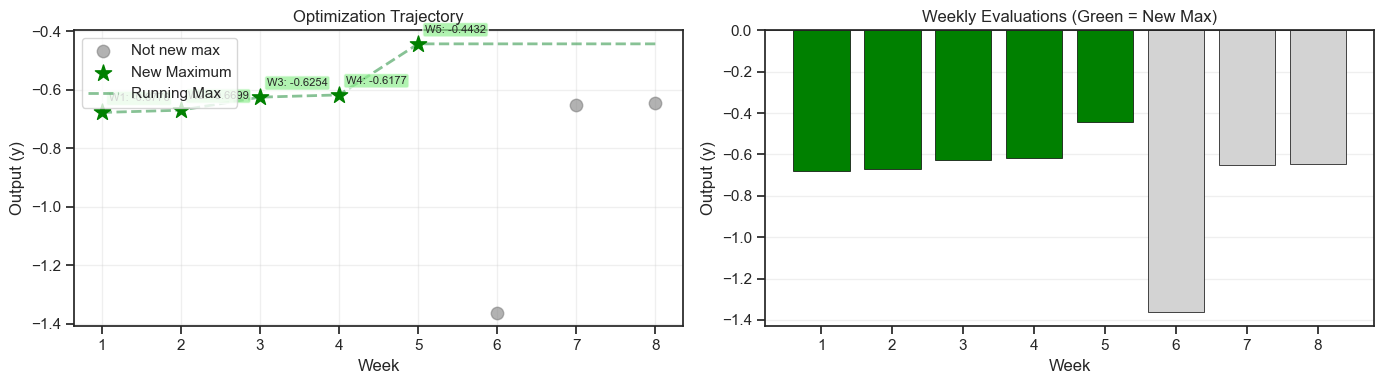

In [3]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

weeks = df_weeks['Week']
y_vals = df_weeks['y']
new_max_mask = df_weeks['New_Max']

# Left plot: Scatter with running max line
ax1.scatter(weeks[~new_max_mask], y_vals[~new_max_mask], color='gray', s=80, alpha=0.6, label='Not new max')
ax1.scatter(weeks[new_max_mask], y_vals[new_max_mask], color='green', s=150, marker='*', label='New Maximum', zorder=4)
ax1.plot(weeks, df_weeks['Running_Max'], 'g--', alpha=0.7, lw=2, label='Running Max')
for _, row in df_weeks[new_max_mask].iterrows():
    ax1.annotate(f"W{int(row['Week'])}: {row['y']:.4f}", xy=(row['Week'], row['y']), 
                 xytext=(5, 8), textcoords='offset points', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.2', fc='lightgreen', alpha=0.7))
ax1.set_xlabel('Week'); ax1.set_ylabel('Output (y)')
ax1.set_title('Optimization Trajectory'); ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.3)

# Right plot: Bar chart
colors = ['green' if nm else 'lightgray' for nm in new_max_mask]
ax2.bar(weeks, y_vals, color=colors, edgecolor='black', lw=0.5)
ax2.axhline(y=0, color='black', lw=0.5)
ax2.set_xlabel('Week'); ax2.set_ylabel('Output (y)')
ax2.set_title('Weekly Evaluations (Green = New Max)'); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Week 8 Result:**
- `(0.477907, 0.146241, 0.495370, 0.945008, 0.013763)` scored **y = -0.6441** — worse than best
- This is the 2nd consecutive disappointing result
- The GP-suggested points keep missing — time to try something different

**Current best remains:** `(0.4712, 0.0960, 0.6215, 0.9025, 0.0561)` at y = -0.4432 (Week 5)


In [4]:
from scipy.stats import norm

# Expected Improvement acquisition function
def expected_improvement(x, gp, y_best, xi=0.01):
    """
    Expected Improvement acquisition function.
    
    Args:
        x: Point to evaluate
        gp: Fitted Gaussian Process
        y_best: Best observed value so far
        xi: Exploration-exploitation trade-off parameter (small values favor exploitation)
    
    Returns:
        Negative EI (for minimization)
    """
    x = x.reshape(1, -1)
    mu, sigma = gp.predict(x, return_std=True)
    
    # Add small epsilon to avoid division by zero
    sigma = sigma + 1e-9
    
    # Calculate improvement
    improvement = mu - y_best - xi
    Z = improvement / sigma
    
    # Expected Improvement formula
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    
    return -ei[0]  # Return negative for minimization


# Boundary penalty function
def boundary_penalty(x, margin=0.15, penalty_strength=2.0):
    """
    Add a penalty for points near the boundaries to avoid extreme values.
    
    Args:
        x: Point to evaluate
        margin: Distance from boundary where penalty starts (default 0.15)
        penalty_strength: Strength of the penalty (default 2.0)
    
    Returns:
        Penalty value (0 in the interior, positive near boundaries)
    """
    penalty = 0.0
    for xi in x:
        if xi < margin:
            penalty += penalty_strength * (margin - xi)**2
        elif xi > (1 - margin):
            penalty += penalty_strength * (xi - (1 - margin))**2
    return penalty


# Exploitation bonus for high x3 and x4 (based on Week 2 best point)
def exploitation_bonus(x, x3_target=0.87, x4_target=0.90, bonus_strength=1.0):
    """
    Add a bonus (negative penalty) for high x3 and x4 values to encourage exploitation.
    This version leans harder on x3 to avoid large downward moves.
    """
    bonus = 0.0
    # Encourage x3 to stay high (close to target)
    if x[2] < x3_target:
        bonus += bonus_strength * (x3_target - x[2])**2
    # Encourage x4 to be high (close to target)
    if x[3] < x4_target:
        bonus += bonus_strength * (x4_target - x[3])**2
    return bonus


# Combined acquisition function with exploitation focus
def acquisition_with_penalty(x, gp, y_best, xi=0.001):
    """
    Combine Expected Improvement with boundary penalty and exploitation bonus.
    Lower xi (0.001) favors exploitation over exploration.
    """
    ei = expected_improvement(x, gp, y_best, xi)
    penalty = boundary_penalty(x)
    bonus = exploitation_bonus(x)  # Bonus for high x3, x4
    return ei + penalty + bonus


# Display current best
y_best = y.max()
best_idx = y.argmax()
print(f"Current best score: {y_best:.4f}")
print(f"Current best recipe: {X[best_idx]}")
print(f"  x1={X[best_idx, 0]:.4f}, x2={X[best_idx, 1]:.4f}, x3={X[best_idx, 2]:.4f}, x4={X[best_idx, 3]:.4f}, x5={X[best_idx, 4]:.4f}")


Current best score: -0.4432
Current best recipe: [0.4712 0.096  0.6215 0.9025 0.0561]
  x1=0.4712, x2=0.0960, x3=0.6215, x4=0.9025, x5=0.0561


## Ensemble Surrogate: GP + Random Forest

Since the GP alone has been misleading us, I'm combining it with a Random Forest. The ensemble averages their predictions and uses their disagreement as a measure of uncertainty.


In [5]:
# Ensemble Surrogate: GP + Random Forest
# ========================================
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.ensemble import RandomForestRegressor

# Current best
best_idx = df['y'].idxmax()
best_point = df.loc[best_idx]
best_y = best_point['y']
print(f"Current best: ({best_point['x1']:.4f}, {best_point['x2']:.4f}, {best_point['x3']:.4f}, {best_point['x4']:.4f}, {best_point['x5']:.4f}) = {best_y:.4f}")
print(f"Week 8 result: -0.6441 (worse than best)\n")

# === Model 1: Gaussian Process ===
gp_kernel = (
    ConstantKernel(1.0, (1e-2, 100.0))
    * Matern(length_scale=[0.2]*5, length_scale_bounds=(0.01, 1.0), nu=2.5)
    + WhiteKernel(noise_level=0.05, noise_level_bounds=(1e-3, 0.5))
)
gp = GaussianProcessRegressor(kernel=gp_kernel, normalize_y=True, n_restarts_optimizer=10, random_state=42)
gp.fit(X, y)
print(f"GP fitted. Kernel: {gp.kernel_}")

# === Model 2: Random Forest ===
rf = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=2, random_state=42, n_jobs=-1)
rf.fit(X, y.ravel())
print(f"Random Forest fitted. Feature importances: x1={rf.feature_importances_[0]:.3f}, x2={rf.feature_importances_[1]:.3f}, x3={rf.feature_importances_[2]:.3f}, x4={rf.feature_importances_[3]:.3f}, x5={rf.feature_importances_[4]:.3f}\n")

# Search region: focus on Week 5 basin with some exploration
sr_x1 = (0.40, 0.55)
sr_x2 = (0.06, 0.15)
sr_x3 = (0.50, 0.70)
sr_x4 = (0.85, 0.95)
sr_x5 = (0.02, 0.10)

print("Search region (focused on Week 5 basin):")
print(f"  x1: [{sr_x1[0]}, {sr_x1[1]}]")
print(f"  x2: [{sr_x2[0]}, {sr_x2[1]}]")
print(f"  x3: [{sr_x3[0]}, {sr_x3[1]}]")
print(f"  x4: [{sr_x4[0]}, {sr_x4[1]}]")
print(f"  x5: [{sr_x5[0]}, {sr_x5[1]}]\n")

# Generate candidate grid
grid_res = 10  # 10^5 = 100,000 candidates
grid_x1 = np.linspace(sr_x1[0], sr_x1[1], grid_res)
grid_x2 = np.linspace(sr_x2[0], sr_x2[1], grid_res)
grid_x3 = np.linspace(sr_x3[0], sr_x3[1], grid_res)
grid_x4 = np.linspace(sr_x4[0], sr_x4[1], grid_res)
grid_x5 = np.linspace(sr_x5[0], sr_x5[1], grid_res)
mesh = np.array(np.meshgrid(grid_x1, grid_x2, grid_x3, grid_x4, grid_x5)).reshape(5, -1).T

print(f"Evaluating {len(mesh)} candidates with ensemble...")

# Get GP predictions
gp_mu, gp_sigma = gp.predict(mesh, return_std=True)

# Get RF predictions (mean and uncertainty from tree disagreement)
rf_tree_preds = np.array([tree.predict(mesh) for tree in rf.estimators_])
rf_mu = rf_tree_preds.mean(axis=0)
rf_sigma = rf_tree_preds.std(axis=0)

# === Ensemble: average predictions, combine uncertainties ===
ensemble_mu = 0.5 * gp_mu + 0.5 * rf_mu  # Equal weight
ensemble_sigma = np.sqrt(0.5 * gp_sigma**2 + 0.5 * rf_sigma**2)  # Combined uncertainty

# Model disagreement as additional uncertainty signal
model_disagreement = np.abs(gp_mu - rf_mu)

# UCB acquisition: balance exploitation (high mu) and exploration (high sigma + disagreement)
beta = 0.3  # Moderate exploration
gamma = 0.2  # Weight for model disagreement
ensemble_ucb = ensemble_mu + beta * ensemble_sigma + gamma * model_disagreement

# Build candidate dataframe
candidates = pd.DataFrame(mesh, columns=['x1', 'x2', 'x3', 'x4', 'x5'])
candidates['gp_mu'] = gp_mu
candidates['gp_sigma'] = gp_sigma
candidates['rf_mu'] = rf_mu
candidates['rf_sigma'] = rf_sigma
candidates['ensemble_mu'] = ensemble_mu
candidates['ensemble_sigma'] = ensemble_sigma
candidates['disagreement'] = model_disagreement
candidates['ucb'] = ensemble_ucb

# Filter: minimum distance from existing observations
min_dist = 0.02
for _, obs in df.iterrows():
    dist = np.sqrt((candidates['x1'] - obs['x1'])**2 + 
                   (candidates['x2'] - obs['x2'])**2 +
                   (candidates['x3'] - obs['x3'])**2 +
                   (candidates['x4'] - obs['x4'])**2 +
                   (candidates['x5'] - obs['x5'])**2)
    candidates = candidates[dist >= min_dist]

print(f"Candidates after distance filter: {len(candidates)}")

# Top candidates by ensemble UCB
top_candidates = candidates.nlargest(10, 'ucb')
print("\nTop 10 Ensemble candidates (by UCB):")
display(top_candidates[['x1', 'x2', 'x3', 'x4', 'x5', 'gp_mu', 'rf_mu', 'ensemble_mu', 'disagreement', 'ucb']])

# Recommended point
if len(top_candidates) > 0:
    rec = top_candidates.iloc[0]
    print(f"\n" + "="*60)
    print("ENSEMBLE RECOMMENDATION")
    print("="*60)
    print(f"Recommended: ({rec['x1']:.6f}, {rec['x2']:.6f}, {rec['x3']:.6f}, {rec['x4']:.6f}, {rec['x5']:.6f})")
    print(f"GP prediction: {rec['gp_mu']:.4f}")
    print(f"RF prediction: {rec['rf_mu']:.4f}")
    print(f"Ensemble mean: {rec['ensemble_mu']:.4f}")
    print(f"Model disagreement: {rec['disagreement']:.4f}")
    print(f"\nSubmission format: {rec['x1']:.6f}-{rec['x2']:.6f}-{rec['x3']:.6f}-{rec['x4']:.6f}-{rec['x5']:.6f}")


Current best: (0.4712, 0.0960, 0.6215, 0.9025, 0.0561) = -0.4432
Week 8 result: -0.6441 (worse than best)



d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a bette

GP fitted. Kernel: 1.2**2 * Matern(length_scale=[0.655, 1, 1, 1, 0.916], nu=2.5) + WhiteKernel(noise_level=0.0186)
Random Forest fitted. Feature importances: x1=0.047, x2=0.173, x3=0.021, x4=0.362, x5=0.396

Search region (focused on Week 5 basin):
  x1: [0.4, 0.55]
  x2: [0.06, 0.15]
  x3: [0.5, 0.7]
  x4: [0.85, 0.95]
  x5: [0.02, 0.1]

Evaluating 100000 candidates with ensemble...
Candidates after distance filter: 99889

Top 10 Ensemble candidates (by UCB):


,x1,x2,x3,x4,x5,gp_mu,rf_mu,ensemble_mu,disagreement,ucb
94508,0.466667,0.15,0.611111,0.85,0.091111,-0.528683,-0.714699,-0.621691,0.186016,-0.532308
95508,0.483333,0.15,0.611111,0.85,0.091111,-0.527270,-0.717488,-0.622379,0.190218,-0.532520
94608,0.466667,0.15,0.633333,0.85,0.091111,-0.529350,-0.714699,-0.622024,0.185349,-0.532821
95608,0.483333,0.15,0.633333,0.85,0.091111,-0.527849,-0.717488,-0.622669,0.189639,-0.532973
95504,0.483333,0.15,0.611111,0.85,0.055556,-0.529356,-0.703251,-0.616304,0.173895,-0.533409
94504,0.466667,0.15,0.611111,0.85,0.055556,-0.531132,-0.700462,-0.615797,0.169329,-0.533454
95604,0.483333,0.15,0.633333,0.85,0.055556,-0.529493,-0.703251,-0.616372,0.173758,-0.533526
94604,0.466667,0.15,0.633333,0.85,0.055556,-0.531362,-0.700462,-0.615912,0.169100,-0.533633
94408,0.466667,0.15,0.588889,0.85,0.091111,-0.529497,-0.715950,-0.622723,0.186453,-0.533826
95408,0.483333,0.15,0.588889,0.85,0.091111,-0.528197,-0.718739,-0.623468,0.190542,-0.534123



ENSEMBLE RECOMMENDATION
Recommended: (0.466667, 0.150000, 0.611111, 0.850000, 0.091111)
GP prediction: -0.5287
RF prediction: -0.7147
Ensemble mean: -0.6217
Model disagreement: 0.1860

Submission format: 0.466667-0.150000-0.611111-0.850000-0.091111


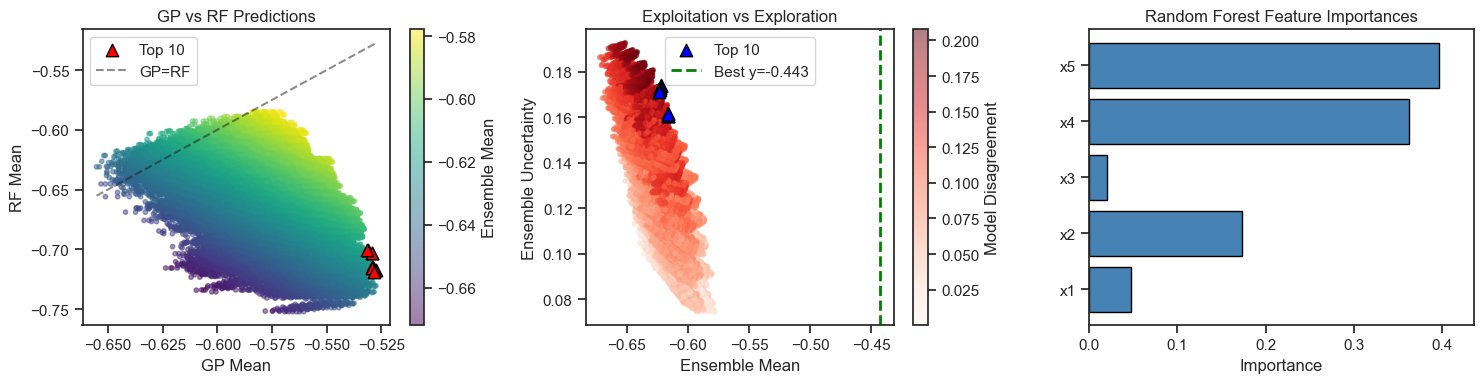

In [6]:
# Visualization: GP vs RF predictions + ensemble
# ================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Get recommended point
if len(top_candidates) > 0:
    rec = top_candidates.iloc[0]

# Plot 1: GP mean vs RF mean for all candidates
ax1 = axes[0]
scatter1 = ax1.scatter(candidates['gp_mu'], candidates['rf_mu'], c=candidates['ensemble_mu'], 
                       cmap='viridis', s=10, alpha=0.5)
ax1.scatter(top_candidates['gp_mu'], top_candidates['rf_mu'], c='red', s=80, 
            edgecolor='black', marker='^', label='Top 10')
ax1.plot([candidates['gp_mu'].min(), candidates['gp_mu'].max()], 
         [candidates['gp_mu'].min(), candidates['gp_mu'].max()], 'k--', alpha=0.5, label='GP=RF')
ax1.set_xlabel('GP Mean')
ax1.set_ylabel('RF Mean')
ax1.set_title('GP vs RF Predictions')
ax1.legend()
plt.colorbar(scatter1, ax=ax1, label='Ensemble Mean')

# Plot 2: Ensemble mean vs uncertainty
ax2 = axes[1]
scatter2 = ax2.scatter(candidates['ensemble_mu'], candidates['ensemble_sigma'], 
                       c=candidates['disagreement'], cmap='Reds', s=10, alpha=0.5)
ax2.scatter(top_candidates['ensemble_mu'], top_candidates['ensemble_sigma'], c='blue', s=80,
            edgecolor='black', marker='^', label='Top 10')
ax2.axvline(x=best_y, color='green', linestyle='--', linewidth=2, label=f'Best y={best_y:.3f}')
ax2.set_xlabel('Ensemble Mean')
ax2.set_ylabel('Ensemble Uncertainty')
ax2.set_title('Exploitation vs Exploration')
ax2.legend()
plt.colorbar(scatter2, ax=ax2, label='Model Disagreement')

# Plot 3: Feature importance from RF
ax3 = axes[2]
features = ['x1', 'x2', 'x3', 'x4', 'x5']
importances = rf.feature_importances_
ax3.barh(features, importances, color='steelblue', edgecolor='black')
ax3.set_xlabel('Importance')
ax3.set_title('Random Forest Feature Importances')
ax3.set_xlim(0, max(importances) * 1.1)

plt.tight_layout()
plt.show()


## Summary and Recommended Point for Week 9

### What happened in Week 8
We probed `(0.4779, 0.1462, 0.4954, 0.9450, 0.0138)` and got **y = -0.6441** — worse than our best (-0.4432).

This is the second consecutive disappointment. The GP kept suggesting points that looked good but weren't.

### Why Ensemble Surrogate this week
I don't trust the GP alone anymore. By combining GP + Random Forest:
- **GP** provides uncertainty estimates and assumes smoothness
- **RF** doesn't assume smoothness and can capture local patterns
- **Ensemble** averages their predictions — if they agree, we're confident; if they disagree, that's extra uncertainty

I also added model disagreement to the acquisition function: points where GP and RF disagree are interesting for exploration.

### Recommended point

**Submission format:** Check the Ensemble output cell above — it prints the exact coordinates.

The point maximizes ensemble UCB (mean + uncertainty + disagreement), staying in the Week 5 basin where our best result lives.

### Honest assessment
The best we've seen is -0.4432 from Week 5. We've been trying to find better regions but keep failing. Maybe the Week 5 point is already near-optimal for this cake recipe. The ensemble at least gives us a more robust prediction.
